In [1]:
%%html
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:wght@300;400;500;600;700&display=swap" rel="stylesheet">

<style>
/* markdown + output */
body, .markdown-body, .jp-RenderedHTMLCommon, div.text_cell_render,
.notebook, .notebook * {
  font-family: "Source Serif 4", serif !important;
}

/* code editor (monaco) */
.monaco-editor, .monaco-editor * {
  font-family: "Source Serif 4", serif !important;
}
</style>

In [1]:
import scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import os
from scipy.stats import *
from scipy.stats import norm, t
import os

In [2]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [3]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='faithful')

(array([45., 36., 13.,  3.,  4., 12., 29., 52., 54., 24.]),
 array([1.6 , 1.95, 2.3 , 2.65, 3.  , 3.35, 3.7 , 4.05, 4.4 , 4.75, 5.1 ]),
 <BarContainer object of 10 artists>)

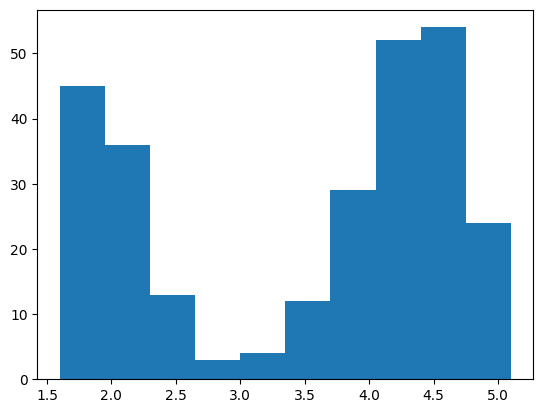

In [4]:
plt.hist(df.eruptions)

In [5]:
scipy.stats.skew(df.eruptions)

np.float64(-0.4158409529189896)

In [6]:
((df.eruptions - np.mean(df.eruptions)) ** 3).sum()/((len(df.eruptions)-1)* np.std(df.eruptions, ddof=1)**3)

np.float64(-0.41507583552214816)

#### Skewness

#### What is Skewness?
Skewness measures the **asymmetry** of a distribution.  
It indicates whether the data stretches more toward the left or right side.

- Positive skewness → tail on the right (right-skewed)
- Negative skewness → tail on the left (left-skewed)
- Zero skewness → perfectly symmetrical

---

#### Skewness Formula (Sample Skewness)

$$
\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum \left( \frac{x_i - \bar{x}}{s} \right)^3
$$

Where:  
- $begin:math:text$ n $end:math:text$ = number of observations  
- $begin:math:text$ \\bar\{x\} $end:math:text$ = sample mean  
- $begin:math:text$ s $end:math:text$ = sample standard deviation  

---

#### Interpretations of Skewness

| Skewness Value | Meaning | Shape |
|----------------|---------|--------|
| 0 | symmetric distribution | normal-like |
| > 0 | right-skewed | long right tail |
| < 0 | left-skewed | long left tail |

---

#### Simple Intuition for Skewness
- Positive skewness → few large values pull the tail to the right  
- Negative skewness → few small values pull the tail to the left  
- Zero skewness → balanced on both sides  

---

#### Python Notes for Skewness

```python
from scipy.stats import skew
skew(data)    # returns sample skewness
```

---

#### Ultra-short memory trick for Skewness
- Right tail → positive  
- Left tail → negative  
- Perfectly balanced → zero  

---

#### Kurtosis vs Excess Kurtosis

#### What is Kurtosis?
Kurtosis measures **how heavy or light the tails** of a distribution are compared to a normal distribution.

- High kurtosis → more extreme values (heavy tails)  
- Low kurtosis → fewer extreme values (light tails)

For a normal distribution, raw kurtosis = 3.

---

#### What is Excess Kurtosis?

Excess kurtosis is defined as:

$$
\text{Excess Kurtosis} = \text{Kurtosis} - 3
$$

This makes the normal distribution easier to compare because its value becomes 0.

- `0` → normal  
- `> 0` → heavy tails (leptokurtic)  
- `< 0` → light tails (platykurtic)

---

#### Comparison Table: Kurtosis vs Excess Kurtosis

| Concept | Value for Normal | Formula | Interpretation | Notes |
|--------|------------------|----------|----------------|-------|
| Kurtosis (raw) | 3 | — | >3 heavy tails, <3 light tails | Classical definition |
| Excess Kurtosis | 0 | Kurtosis − 3 | >0 heavy tails, <0 light tails | SciPy default |

---

#### Types of Kurtosis

| Type | Excess Kurtosis | Tail Behavior | Shape |
|------|------------------|---------------|--------|
| Mesokurtic | 0 | Normal tails | Bell-shaped |
| Leptokurtic | > 0 | Heavy tails, many extremes | Sharp peak |
| Platykurtic | < 0 | Light tails, few extremes | Flat peak |

---

<img src="https://res.cloudinary.com/jerrick/image/upload/d_642250b563292b35f27461a7.png,f_jpg,fl_progressive,q_auto,w_1024/649146d1744395001d91a13b.jpg" width="30%">

mesokurtic is normal distribution

---

#### Simple Intuition
- Excess Kurtosis = 0 → normal  
- Positive → more outliers  
- Negative → fewer outliers  

Excess kurtosis simply sets the normal curve's baseline to 0.

---

#### Ultra-short memory trick
- Excess kurtosis = kurtosis − 3  
- Normal → 0  
- Positive → heavy tails  
- Negative → light tails  

In [7]:
x1 = np.repeat([1,2,3,4,5,6,7,8,9,10],[5,10,150,140,120,100,80,60,40,20])

(array([  5.,  10., 150., 140., 120., 100.,  80.,  60.,  40.,  20.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

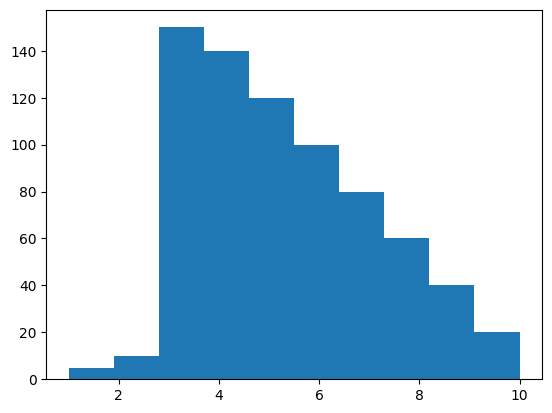

In [8]:
plt.hist(x1)

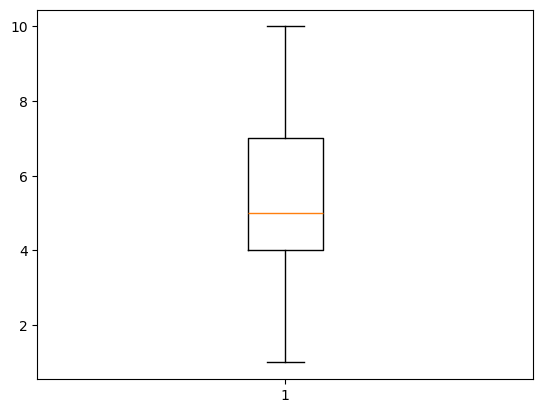

In [9]:
plt.boxplot(x1)
plt.show()

In [10]:
np.mean(x1)

np.float64(5.289655172413793)

In [11]:
np.median(x1)

np.float64(5.0)

In [12]:
len(df.eruptions)

272

In [13]:
# slicing the data into 2 equal parts

e1 = df.eruptions[136:]
e2 = df.eruptions[:136]

/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_80669/3390848912.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([e1, e2], labels=['Series 1', 'Series 2'])


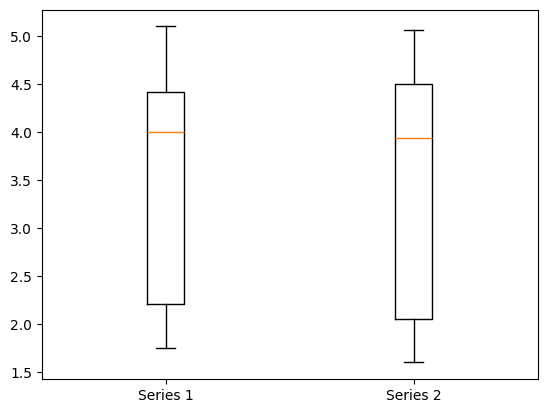

In [14]:
plt.boxplot([e1, e2], labels=['Series 1', 'Series 2'])
plt.show()

In [15]:
df = pd.read_excel('data/Marks.xlsx')

In [16]:
df.head()

,Subject,Trainer,Marks
0,Calculus,Sudeep,65
1,Calculus,Sudeep,75
2,Calculus,Sudeep,86
3,Calculus,Sudeep,82
4,Calculus,Sudeep,75


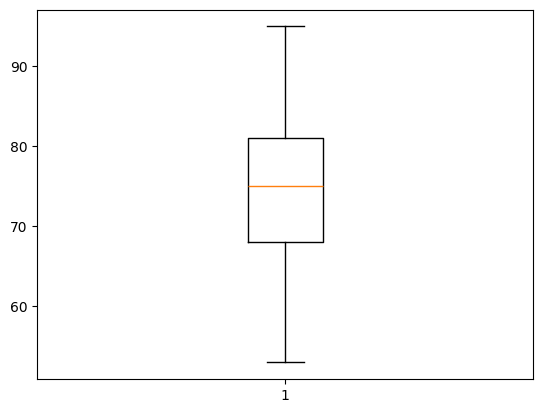

In [17]:
plt.boxplot(df.Marks)
plt.show()

#### groped boxplots


[6     64
7     67
8     71
9     75
10    81
17    63
18    65
19    75
20    81
21    71
22    65
23    74
24    68
25    76
32    69
33    61
34    57
35    81
36    68
37    53
38    84
39    72
40    68
Name: Marks, dtype: int64]
[6     64
7     67
8     71
9     75
10    81
17    63
18    65
19    75
20    81
21    71
22    65
23    74
24    68
25    76
32    69
33    61
34    57
35    81
36    68
37    53
38    84
39    72
40    68
Name: Marks, dtype: int64, 0     65
1     75
2     86
3     82
4     75
5     68
11    95
12    87
13    83
14    74
15    68
16    81
26    84
27    84
28    86
29    91
30    78
31    77
Name: Marks, dtype: int64]


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_80669/4254942189.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(mylist, labels = lab)


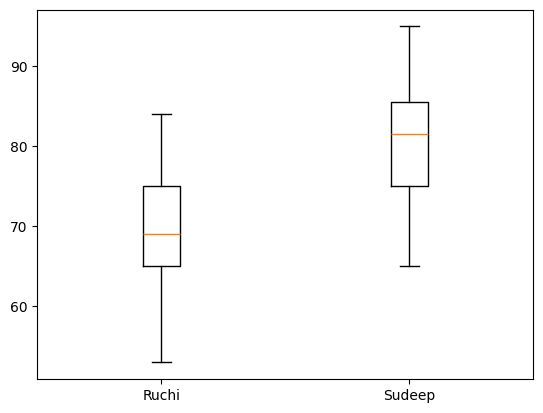

In [ ]:
mylist = []
lab = []
for ctr in np.unique(df.Trainer):
    mylist.append(df.Marks[df.Trainer == ctr])
    lab.append(ctr)
    print(mylist)

plt.boxplot(mylist, labels = lab)
plt.show()

In [19]:
df.Subject.unique()

array(['Calculus', 'Statistics', 'Trigno'], dtype=object)

In [ ]:
# groped boxplots
# continious data (label) -> categorize -> subcategorize

mylist = []
lab = []
for ctr1 in np.unique(df.Trainer):
    for ctr2 in np.unique(df.Subject):
        mylist.append(df.Marks[(df.Trainer==ctr1) & (df.Subject == ctr2)])
        lab.append([ctr1, ctr2])
plt.boxplot(mylist, labels= lab)
plt.xticks(rotation = 90)
plt.show()


In [21]:
# in the lecture total of 9 hours the train horns for 20 times, there is exam of 1 hours in between, so what is the probablity of honks in the 1 hour

In [22]:
mtbf = 9/20
mtbf

0.45

In [23]:
from scipy.stats import expon

In [24]:
expon.cdf(1, scale = 0.45)

np.float64(0.8916319767781041)

In [25]:
1 - expon.cdf(1, scale = 0.45)

np.float64(0.10836802322189587)

In [26]:
# avg amount of water in bottle is 990 ml with STD of 20ml, probablity of getting 1 or more litre of water

In [27]:
1 - norm.cdf(1000, 990, 20)

np.float64(0.3085375387259869)

In [28]:
# avg = 17 what is the probablity i will reach in 15-19 hours

In [29]:
prob = norm.cdf(19, 17, 1) - norm.cdf(15, 17, 1)
prob

np.float64(0.9544997361036416)

In [30]:
# for any normal bell shaped curve 68.26 percent of the area falls between  +1 and -1 distribution from the mean
# for example for this ->  avg = 17 what is the probablity i will reach in 16-18 hours

![image](https://media.geeksforgeeks.org/wp-content/uploads/20210525140711/empiricalrule-660x388.png)

In [31]:
norm.cdf(1) - norm.cdf(-1)

np.float64(0.6826894921370859)

In [32]:
norm.cdf(2) - norm.cdf(-2)

np.float64(0.9544997361036416)

In [33]:
norm.cdf(3) - norm.cdf(-3)

np.float64(0.9973002039367398)

In [34]:
df.head()

,Subject,Trainer,Marks
0,Calculus,Sudeep,65
1,Calculus,Sudeep,75
2,Calculus,Sudeep,86
3,Calculus,Sudeep,82
4,Calculus,Sudeep,75


In [35]:
norm.ppf(0.9, 5, 1)

np.float64(6.2815515655446)

In [36]:
from scipy.stats import t

In [37]:
# normal distribution


# we need to calculate the value of z and give input
# 2nd - degrees of freedom i.e(no(sample)-1)


# in python we need to explicity store the mu sigma in variable, python doesn't take it direclty

In [38]:
# time taken from mumbai to kolhapur is 5 hours and sd = 1.4 hours calculated on the basis of 15 trips

# so degrees of freedom = sample size -1 = 14

In [39]:
# Q1. what is the probablity of taking less than 5.6 hours

z = (5.6-5)/1.4
t.cdf(z, 14)

np.float64(0.6626221087121706)

In [40]:
# what is the probablity of taking more than 5.6 hours
t.sf(z,14)

np.float64(0.33737789128782925)

In [41]:
# what is the probablity of taking time b/w 4.5 and 5.6

z1 = (4.5-5)/1.4
z2 = (5.6-5)/1.4

In [42]:
t.cdf(z2, 14) - t.cdf(z1,14)

np.float64(0.29946661799007335)

In [ ]:
# t distribution can be used with all sample sizes
# normal distribution can be used only when the sample size is > 30 and population is STD is known
# as the sample size increases the values that we get from t distribution will get close and closer to the values of normal distribution

In [ ]:
# mean = 5 sd = 1.3, what is the probablity of < 5.4

In [45]:
org = norm.cdf(5.4,5,1.3)
org

np.float64(0.6208417632368549)

In [46]:
z = (5.4-5) / 1.3

In [47]:
# look how does the t2 gets closer to our org distribution

In [48]:
t1 = t.cdf(z,14)
t1

np.float64(0.6185768199132399)

In [49]:
t2 = t.cdf(z,500)
t2

np.float64(0.6207777003768674)

### Understanding t Distribution vs Normal Distribution

### Normal Distribution
- **Shape:** Bell-shaped, symmetric.
- **When to use:** When population standard deviation (σ) is known and/or sample size is large (n > 30).
- **Formula:** Uses mean (μ) and standard deviation (σ).
- **Example:** Heights of adults, IQ scores.

#### Example (Normal Distribution)
Suppose travel time from Mumbai to Kolhapur is normally distributed with mean μ = 17 hours and σ = 1 hour.
- **Q:** What is the probability of reaching in 15–19 hours?
- **A:** Use CDF for normal distribution:

In [51]:
df.head()

,Subject,Trainer,Marks
0,Calculus,Sudeep,65
1,Calculus,Sudeep,75
2,Calculus,Sudeep,86
3,Calculus,Sudeep,82
4,Calculus,Sudeep,75


In [ ]:
mylist = []
lab = []
for ctr in np.unique(df.Trainer):
    mylist.append(df.Marks[df.Trainer == ctr])
    lab.append(ctr)
    print(mylist)

plt.boxplot(mylist, labels = lab)
plt.show()

[0     65
1     75
2     86
3     82
4     75
5     68
6     64
7     67
8     71
9     75
10    81
Name: Marks, dtype: int64, 11    95
12    87
13    83
14    74
15    68
16    81
17    63
18    65
19    75
20    81
21    71
22    65
23    74
24    68
25    76
Name: Marks, dtype: int64, 26    84
27    84
28    86
29    91
30    78
31    77
32    69
33    61
34    57
35    81
36    68
37    53
38    84
39    72
40    68
Name: Marks, dtype: int64]
['Calculus', 'Statistics', 'Trigno']


/var/folders/57/62f2rv1j4w94h8tfp_c43b1c0000gn/T/ipykernel_80669/1606882670.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(mylist, labels = lab)


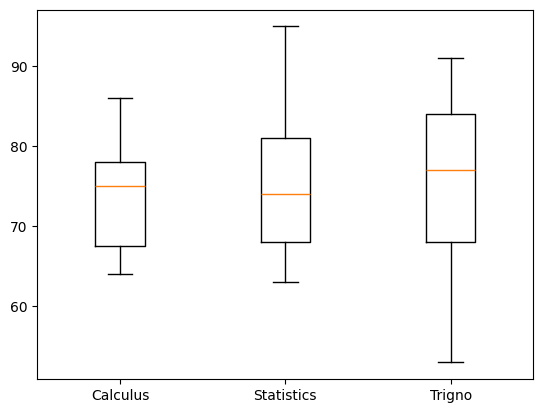

In [73]:
mylist = []
lab = []
for ctr in np.unique(df.Subject):
    mylist.append(df.Marks[df.Subject == ctr])
    lab.append(ctr)
print(mylist)
print(lab)


plt.boxplot(mylist, labels = lab)
plt.show()

In [58]:
norm.ppf(0.025)

np.float64(-1.9599639845400545)

In [59]:
norm.ppf(0.975)

np.float64(1.959963984540054)

In [61]:
x = norm.ppf(0.025, 0.975)

In [70]:
norm.ppf(0.99999999999999)

np.float64(7.650730905155642)